In [3]:
import pandas as pd
import numpy as np

# 创建一个示例 DataFrame
df = pd.DataFrame({
    '姓名': ['张三', '李四', '王五', '赵六', '张三', '钱七'],
    '语文': [85, 92, 78, 95, 85, 88],
    '数学': [90, 85, 96, 88, 90, 72],
    '英语': [78, 90, 85, 92, 78, 80]
})
print("原始数据：")
print(df)
print()

# ========== 1. 直接使用 NumPy 的函数 ==========
print("=" * 50)
print("1. 直接在 DataFrame 上使用 numpy 函数")
print("=" * 50)
print(np.mean(df[['语文', '数学', '英语']]))
print()
print(np.sqrt(df[['语文', '数学', '英语']]).head())
print()

# ========== 2. 排序: sort_index() 和 sort_values() ==========
print("=" * 50)
print("2. 排序：sort_index() 和 sort_values()")
print("=" * 50)
print("按姓名排序（sort_values）：")
print(df.sort_values('姓名'))
print()
print("按语文降序排序：")
print(df.sort_values('语文', ascending=False))
print()
print("按索引排序（sort_index）：")
print(df.sort_index(ascending=False))
print()

# ========== 3. 唯一值: unique() ==========
print("=" * 50)
print("3. 唯一值：unique()")
print("=" * 50)
print("姓名列的唯一值：")
print(df['姓名'].unique())
print()

# ========== 4. 统计值出现的次数: value_counts() ==========
print("=" * 50)
print("4. 统计值出现的次数：value_counts()")
print("=" * 50)
print("每个姓名出现的次数：")
print(df['姓名'].value_counts())
print()

# ========== 5. 判断值是否存在: isin() ==========
print("=" * 50)
print("5. 判断值是否存在：isin()")
print("=" * 50)
print("语文成绩是否在 [85, 90] 中：")
print(df['语文'].isin([85, 90]))
print()
print("筛选出语文成绩为 85 或 90 的行：")
print(df[df['语文'].isin([85, 90])])
print()

# ========== 6. apply() — 应用聚合/转换函数 ==========
print("=" * 50)
print("6. apply() — 在 DataFrame 上应用函数")
print("=" * 50)
print("对每一列求范围（最大值-最小值）：")
print(df[['语文', '数学', '英语']].apply(lambda x: x.max() - x.min()))
print()
print("对每一行求总分：")
df['总分'] = df[['语文', '数学', '英语']].apply(lambda row: row.sum(), axis=1)
print(df)
print()

# ========== 7. applymap() / map() — 元素级映射 ==========
print("=" * 50)
print("7. map() — 元素级一对一映射")
print("=" * 50)
# map() 用于 Series
print("将姓名映射为英文名：")
name_map = {'张三': 'Zhang San', '李四': 'Li Si', '王五': 'Wang Wu', '赵六': 'Zhao Liu', '钱七': 'Qian Qi'}
print(df['姓名'].map(name_map))
print()

# applymap() 已过时，现在用 map() 操作 DataFrame
print("使用 DataFrame.map() 将成绩映射为等级：")
def score_to_level(score):
    if score >= 90:
        return '优秀'
    elif score >= 80:
        return '良好'
    elif score >= 70:
        return '中等'
    else:
        return '不及格'

print(df[['语文', '数学', '英语']].map(score_to_level))
print()

# ========== 8. apply() 聚合函数综合示例 ==========
print("=" * 50)
print("8. apply() 聚合函数综合示例")
print("=" * 50)
agg_result = df[['语文', '数学', '英语']].agg(['mean', 'std', 'min', 'max', 'median'])
print(agg_result)
print()

# ========== 9. 缺失值判断: isnull() ==========
print("=" * 50)
print("9. 缺失值判断：isnull()")
print("=" * 50)
# 先创建一个含缺失值的 DataFrame
df2 = df.copy()
df2.loc[1, '语文'] = np.nan
df2.loc[3, '数学'] = None
print("含缺失值的 DataFrame：")
print(df2)
print()
print("每个位置是否为缺失值（isnull()）：")
print(df2.isnull())
print()
print("每列有多少个缺失值：")
print(df2.isnull().sum())
print()

# ========== 10. 丢弃缺失值: dropna() ==========
print("=" * 50)
print("10. 丢弃缺失值：dropna()")
print("=" * 50)
print("丢弃任何包含缺失值的行（默认 how='any'）：")
print(df2.dropna())
print()
print("丢弃全部为缺失值的行（how='all'）：")
df2.loc[5, ['语文', '数学', '英语']] = np.nan
print(df2)
print()
print("丢弃全部为缺失值的行：")
print(df2.dropna(how='all'))
print()
print("丢弃指定列有缺失值的行（subset）：")
df3 = df.copy()
df3.loc[1, '语文'] = np.nan
df3.loc[4, '姓名'] = None
print(df3)
print()
print("只检查'语文'列是否有缺失：")
print(df3.dropna(subset=['语文']))
print()

# ========== 11. 填充缺失值: fillna() ==========
print("=" * 50)
print("11. 填充缺失值：fillna()")
print("=" * 50)
df4 = df.copy()
df4.loc[1, '语文'] = np.nan
df4.loc[3, '数学'] = None
df4.loc[5, '英语'] = np.nan
print("原始含缺失值数据：")
print(df4)
print()
print("用固定值填充（fillna(0)）：")
print(df4.fillna(0))
print()
print("用每列的平均值填充：")
print(df4.fillna(df4[['语文', '数学', '英语']].mean()))
print()
print("用前一个有效值填充（ffill()）：")
print(df4.ffill())
print()

# ========== 12. 删除行重复数据: drop_duplicates() ==========
print("=" * 50)
print("12. 删除行重复数据：drop_duplicates()")
print("=" * 50)
print("原始数据（张三有重复）：")
print(df)
print()
print("删除完全重复的行：")
print(df.drop_duplicates())
print()
print("按指定列去重（'姓名'列），保留第一次出现的：")
print(df.drop_duplicates(subset=['姓名']))
print()
print("按指定列去重，保留最后一次出现的：")
print(df.drop_duplicates(subset=['姓名'], keep='last'))

原始数据：
   姓名  语文  数学  英语
0  张三  85  90  78
1  李四  92  85  90
2  王五  78  96  85
3  赵六  95  88  92
4  张三  85  90  78
5  钱七  88  72  80

1. 直接在 DataFrame 上使用 numpy 函数
85.94444444444444

         语文        数学        英语
0  9.219544  9.486833  8.831761
1  9.591663  9.219544  9.486833
2  8.831761  9.797959  9.219544
3  9.746794  9.380832  9.591663
4  9.219544  9.486833  8.831761

2. 排序：sort_index() 和 sort_values()
按姓名排序（sort_values）：
   姓名  语文  数学  英语
0  张三  85  90  78
4  张三  85  90  78
1  李四  92  85  90
2  王五  78  96  85
3  赵六  95  88  92
5  钱七  88  72  80

按语文降序排序：
   姓名  语文  数学  英语
3  赵六  95  88  92
1  李四  92  85  90
5  钱七  88  72  80
0  张三  85  90  78
4  张三  85  90  78
2  王五  78  96  85

按索引排序（sort_index）：
   姓名  语文  数学  英语
5  钱七  88  72  80
4  张三  85  90  78
3  赵六  95  88  92
2  王五  78  96  85
1  李四  92  85  90
0  张三  85  90  78

3. 唯一值：unique()
姓名列的唯一值：
['张三' '李四' '王五' '赵六' '钱七']

4. 统计值出现的次数：value_counts()
每个姓名出现的次数：
姓名
张三    2
李四    1
王五    1
赵六    1
钱七    1
Name: count, dtype: int64



In [5]:
# ============================================================
# 综合案例：训练神经网络前的完整数据预处理流程
# 模拟场景：房价预测（面积、房间数、楼层、朝向 → 价格）
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# ---- 1. 创建原始数据（含缺失值、重复值、文本特征）----
print("=" * 60)
print("1. 原始数据（含缺失值、重复值、类别特征）")
print("=" * 60)

raw_data = pd.DataFrame({
    '面积':     [108, 85, 130, 95, 120, 108, 150, np.nan, 110, 95],
    '房间数':   [4, 3, 5, 3, 4, 4, 6, 4, np.nan, 3],
    '楼层':     [12, 5, 20, 8, 15, 12, 25, 10, 14, 8],
    '朝向':     ['南', '北', '南', '东', '南', '南', '北', '西', '东', '东'],
    '价格(万)': [350, 260, 420, 290, 380, 350, 480, 310, 330, 290]  # 目标值
})
print(raw_data)
print(f"\n形状: {raw_data.shape}")
print(f"重复行数: {raw_data.duplicated().sum()}")
print(f"缺失值统计:\n{raw_data.isnull().sum()}")
print()

# ---- 2. 数据清洗 ----
print("=" * 60)
print("2. 数据清洗")
print("=" * 60)

# 2a. 删除重复行（用 .copy() 避免 SettingWithCopyWarning）
data_clean = raw_data.drop_duplicates().copy()
print(f"去重后形状: {data_clean.shape}")

# 2b. 处理缺失值
#     数值列用中位数填充（比均值更抗异常值）
for col in ['面积', '房间数']:
    data_clean.loc[:, col] = data_clean[col].fillna(data_clean[col].median())
print(f"缺失值处理后形状: {data_clean.shape}")
print(f"缺失值剩余: {data_clean.isnull().sum().sum()}")
print(data_clean)
print()

# ---- 3. 特征工程 ----
print("=" * 60)
print("3. 特征工程")
print("=" * 60)

# 3a. 类别特征编码：LabelEncoder（朝向 → 数值）
label_encoder = LabelEncoder()
data_clean.loc[:, '朝向编码'] = label_encoder.fit_transform(data_clean['朝向'])
print(f"朝向映射: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# 3b. 创建新特征：单价（万元/㎡）
data_clean.loc[:, '单价'] = data_clean['价格(万)'] / data_clean['面积']
print(data_clean[['面积', '朝向', '朝向编码', '价格(万)', '单价']])
print()

# ---- 4. 特征缩放（标准化 & 归一化）----
print("=" * 60)
print("4. 特征缩放（解决截图里提到的量纲问题）")
print("=" * 60)

feature_cols = ['面积', '房间数', '楼层', '朝向编码']
X = data_clean[feature_cols].values
y = data_clean['价格(万)'].values

print("缩放前特征范围：")
for i, col in enumerate(feature_cols):
    print(f"  {col}: [{X[:, i].min():.1f}, {X[:, i].max():.1f}]")

# 4a. 标准化（Z-score）→ 适合神经网络
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)
print("\n标准化后（均值≈0，标准差≈1）：")
for i, col in enumerate(feature_cols):
    print(f"  {col}: 均值={X_standard[:, i].mean():.2f}, 标准差={X_standard[:, i].std():.2f}")

# 4b. 归一化（MinMax）→ 缩放到 [0,1]
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)
print("\n归一化后（范围[0,1]）：")
for i, col in enumerate(feature_cols):
    print(f"  {col}: [{X_minmax[:, i].min():.2f}, {X_minmax[:, i].max():.2f}]")
print()

# ---- 5. 划分训练集 & 测试集 ----
print("=" * 60)
print("5. 划分训练集 / 测试集（80% / 20%）")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_standard, y, test_size=0.2, random_state=42
)
print(f"训练集: {X_train.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")
print()

# ---- 6. 转为 PyTorch 张量 ----
print("=" * 60)
print("6. 转为 PyTorch 张量，准备输入神经网络")
print("=" * 60)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"X_test:  {X_test_tensor.shape}, y_test:  {y_test_tensor.shape}")
print()

# ---- 7. 快速演示：用预处理后的数据训练一个简单的神经网络 ----
print("=" * 60)
print("7. 简单神经网络训练演示")
print("=" * 60)

model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(X_test_tensor), y_test_tensor)
        print(f"Epoch {epoch:3d} | 训练损失: {loss.item():.4f} | 测试损失: {test_loss.item():.4f}")

print("\n✅ 数据预处理全流程完成！")
print("   原始杂乱数据 → 清洗 → 编码 → 缩放 → 数据集 → 模型就绪")

1. 原始数据（含缺失值、重复值、类别特征）
      面积  房间数  楼层 朝向  价格(万)
0  108.0  4.0  12  南    350
1   85.0  3.0   5  北    260
2  130.0  5.0  20  南    420
3   95.0  3.0   8  东    290
4  120.0  4.0  15  南    380
5  108.0  4.0  12  南    350
6  150.0  6.0  25  北    480
7    NaN  4.0  10  西    310
8  110.0  NaN  14  东    330
9   95.0  3.0   8  东    290

形状: (10, 5)
重复行数: 2
缺失值统计:
面积       1
房间数      1
楼层       0
朝向       0
价格(万)    0
dtype: int64

2. 数据清洗
去重后形状: (8, 5)
缺失值处理后形状: (8, 5)
缺失值剩余: 0
      面积  房间数  楼层 朝向  价格(万)
0  108.0  4.0  12  南    350
1   85.0  3.0   5  北    260
2  130.0  5.0  20  南    420
3   95.0  3.0   8  东    290
4  120.0  4.0  15  南    380
6  150.0  6.0  25  北    480
7  110.0  4.0  10  西    310
8  110.0  4.0  14  东    330

3. 特征工程
朝向映射: {'东': np.int64(0), '北': np.int64(1), '南': np.int64(2), '西': np.int64(3)}
      面积 朝向  朝向编码  价格(万)        单价
0  108.0  南     2    350  3.240741
1   85.0  北     1    260  3.058824
2  130.0  南     2    420  3.230769
3   95.0  东     0    290  3.052632
4  120.0 

## 🤝 KNN（K-近邻）算法详解

### 1. 核心思想：近朱者赤

> **"告诉你一个东西是什么，就看它最像的那 k 个邻居"**

KNN 是机器学习中最直观的算法——不需要训练过程，只是把训练数据存起来，等新数据来了，找最近的 k 个邻居投票。

### 2. k 值的含义

```
k = 1  → 只看最近那一个邻居（容易受噪声干扰，过拟合）
k = 5  → 找最近的 5 个邻居投票（折中，常用）
k 很大 → 考虑太多远距离样本，反而模糊了局部特征（欠拟合）
```

**k 选择技巧：**
- 通常取 1~20 之间的奇数（避免平局）
- 用交叉验证选最优 k
- k 太小 → **过拟合**（只看到最近的噪声）
- k 太大 → **欠拟合**（把远处的样本也拉进来）

### 3. 距离度量

KNN 靠"距离"判断相似度，最常用**欧氏距离**：

$$d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

这正是数据预处理中 `np.sqrt(np.sum((X - centroid)**2, axis=1))` 做的事。

### 4. 为什么必须做特征缩放？

回到房价预测的例子：

| 特征 | 范围 | 对距离的影响 |
|:---|:---:|:---:|
| 面积 | 85 ~ 150 ㎡ | **主导距离计算** |
| 房间数 | 3 ~ 6 个 | 几乎被淹没 |

面积差 50 ㎡ ≈ 房间数差 50 倍的影响力 → **KNN 只看面积，忽略房间数** ❌

标准化后所有特征均值为 0、标准差为 1 → **每个特征平等投票** ✅

### 5. KNN 的优缺点

| 优点 | 缺点 |
|:---|:---|
| 简单直观，无需训练 | 预测时需要计算全部样本距离，慢 |
| 适合多分类问题 | 对特征缩放敏感 |
| 对新数据友好 | 维度灾难（特征太多时效果差） |

### 6. 数学建模比赛中的应用

- 🏆 **手写数字识别**（MNIST）：像素值作为特征，KNN 判断是哪个数字
- 🏆 **鸢尾花分类**（Iris）：花萼/花瓣长宽，KNN 判断品种
- 🏆 **泰坦尼克生存预测**（Titanic）：乘客信息预测是否幸存 ← **这就是我们的例子**

---

## 🎯 K-means 聚类详解

### 1. 核心思想：人以群分

> **"没有标准答案，让数据自己找到组织"**

K-means 是无监督学习——给一堆数据，算法自动把它们分成 k 个簇（群体），使簇内样本尽可能相似，簇间样本尽可能不同。

### 2. 算法步骤（4 步迭代）

```
第 1 步：选 k 个初始质心（随便挑 k 个样本）
第 2 步：每个样本 → 计算到各质心的距离 → 归到最近的簇
第 3 步：每个簇 → 重新计算质心（取簇内所有点的均值）
第 4 步：重复 2~3，直到质心不再变化（收敛）
```

就像你截图里的过程：设置 k=2 → 选 P1、P2 做质心 → 计算距离 → 选举大会 → 重选质心 → 第二届选举大会 → 直到稳定。

### 3. 手肘法选 k

k 选多少？用**手肘法**：

```python
# 尝试不同的 k，看 SSE（簇内误差平方和）下降速度
for k in range(1, 10):
    SSE 随 k 增大而减小
    # 拐点（手肘）处就是最优 k
```

```
SSE
│
│    \
│     \____   ← 手肘点（最优 k）
│          \______
│               \________
└───┴───┴───┴───┴───┴───→ k
    1   2   3   4   5   6
```

**解释：** k 越多，SSE 自然越低，但到某个点后下降变缓——那个拐点就是"性价比最高"的 k。

### 4. K-means 的优缺点

| 优点 | 缺点 |
|:---|:---|
| 简单快速，适合大数据 | 需要预先指定 k |
| 算法容易理解 | 对初始质心选择敏感 |
| 聚类效果好（簇是球形时） | 只能发现球形簇，不能发现奇怪形状 |

### 5. 数学建模比赛中的应用

- 🏆 **客户分群**：根据消费行为把客户分成 k 类，针对性营销
- 🏆 **图像压缩**：把颜色聚类成 k 种，大幅减小图片体积
- 🏆 **异常检测**：远离所有簇中心的点可能是异常数据

---

## 🔄 KNN vs K-means：名字像，但完全不同

| 对比项 | **KNN（分类）** | **K-means（聚类）** |
|:---|---:|:---:|
| **学习方式** | 🏫 **有监督** — 需要已知标签 | 🤖 **无监督** — 没有标签 |
| **K 的含义** | 邻居个数（投票人数） | 簇的数量（分几组） |
| **在做什么** | 新样本 → 看 k 个邻居投票 | 数据 → 自动分成 k 个簇 |
| **有无训练** | 无训练，存数据即"训练" | 迭代更新质心直到收敛 |
| **距离计算** | 新样本 vs 所有已知样本 | 每个样本 vs 当前质心 |

**共同点：** 都用欧氏距离，都依赖特征缩放！

**类比理解：**
- **KNN**：你转学到一个新班级 → 看周围 k 个同学在聊什么 → 加入他们
- **K-means**：老师观察全班 → 发现分成 k 个小圈子，标出每个圈子的中心人物


In [1]:
# ============================================================
# KNN 分类 — Titanic 生存预测
# KNN 是距离敏感算法，特征缩放至关重要！
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- 1. 读取数据 ----
df_knn = pd.read_csv('titanic_train.csv')
print("=" * 60)
print("1. 原始数据")
print("=" * 60)
print(f"形状: {df_knn.shape}\n")

# ---- 2. 特征选择与预处理 ----
print("=" * 60)
print("2. 特征选择与预处理")
print("=" * 60)

# 挑选特征列
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

data = df_knn[features + [target]].copy()
print(f"选定特征: {features}")
print(f"目标列: {target}\n")

# 2a. 处理缺失值
print("处理前缺失值:")
print(data.isnull().sum())

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
print(f"\n处理后缺失值: {data.isnull().sum().sum()}\n")

# 2b. 类别特征编码
label_encoder_sex = LabelEncoder()
data['Sex'] = label_encoder_sex.fit_transform(data['Sex'])  # male→1, female→0

label_encoder_emb = LabelEncoder()
data['Embarked'] = label_encoder_emb.fit_transform(data['Embarked'])

print(f"Sex 映射: {dict(zip(label_encoder_sex.classes_, label_encoder_sex.transform(label_encoder_sex.classes_)))}")
print(f"Embarked 映射: {dict(zip(label_encoder_emb.classes_, label_encoder_emb.transform(label_encoder_emb.classes_)))}")
print()

# 2c. 分离特征和目标
X = data[features].values
y = (data[target] == 'Yes').astype(int).values  # Yes→1, No→0
print(f"类别分布: {np.bincount(y)} (0=未幸存, 1=幸存)")

# ---- 3. 划分数据集 ----
print("\n" + "=" * 60)
print("3. 划分训练集 / 测试集（80% / 20%）")
print("=" * 60)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集: {X_train.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")

# ---- 4. 特征缩放（KNN 必须！）----
print("\n" + "=" * 60)
print("4. 特征缩放 — KNN 基于距离，量纲不同会主导结果")
print("=" * 60)
print("缩放前特征范围:")
for i, col in enumerate(features):
    print(f"  {col:12s} [{X_train[:, i].min():10.2f}, {X_train[:, i].max():10.2f}]")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n缩放后（均值≈0，标准差≈1）:")
for i, col in enumerate(features):
    print(f"  {col:12s} 均值={X_train_scaled[:, i].mean():.2f}, 标准差={X_train_scaled[:, i].std():.2f}")

# ---- 5. KNN 分类 ----
print("\n" + "=" * 60)
print("5. KNN 分类（k=5）")
print("=" * 60)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\n分类报告:\n{classification_report(y_test, y_pred, target_names=['未幸存', '幸存'])}")

# ---- 6. 尝试不同的 k 值 ----
print("=" * 60)
print("6. 不同 k 值的效果对比")
print("=" * 60)
for k in [1, 3, 5, 7, 9, 15, 21]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    acc = knn_k.score(X_test_scaled, y_test)
    print(f"  k={k:2d}  准确率: {acc:.4f} ({acc*100:.2f}%)")

print("\n✅ 结论: KNN 对特征缩放敏感，标准化后效果显著提升")

1. 原始数据
形状: (891, 12)

2. 特征选择与预处理
选定特征: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
目标列: Survived

处理前缺失值:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

处理后缺失值: 0

Sex 映射: {'female': np.int64(0), 'male': np.int64(1)}
Embarked 映射: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}

类别分布: [548 343] (0=未幸存, 1=幸存)

3. 划分训练集 / 测试集（80% / 20%）
训练集: 712 条
测试集: 179 条

4. 特征缩放 — KNN 基于距离，量纲不同会主导结果
缩放前特征范围:
  Pclass       [      1.00,       3.00]
  Sex          [      0.00,       1.00]
  Age          [      0.42,      80.00]
  SibSp        [      0.00,       8.00]
  Parch        [      0.00,       6.00]
  Fare         [      0.00,     512.33]
  Embarked     [      0.00,       2.00]

缩放后（均值≈0，标准差≈1）:
  Pclass       均值=0.00, 标准差=1.00
  Sex          均值=-0.00, 标准差=1.00
  Age          均值=-0.00, 标准差=1.00
  SibSp        均值=0.00, 标准差=1.00
  Parch        均值=0.00, 标准差=1.00
  Fare         

1. 生成模拟数据（5 个自然簇）
数据形状: (150, 2)
前 5 个样本:
[[ 0.71026118  3.20602344]
 [-2.01230248 10.47760382]
 [ 1.1382531   5.4358547 ]
 [ 5.02620442  1.86150081]
 [-8.57855637  7.90149899]]

2. K-means 聚类（k=5）
簇标签: [3 4 3 0 1 2 4 4 3 1 0 0 0 1 2 0 1 0 2 2 4 3 1 1 2 1 1 4 4 0 2 4 4 1 0 2 1
 1 3 4 0 1 4 0 3 0 4 2 0 0 0 0 2 4 4 2 0 2 2 4 1 3 0 2 1 2 3 2 1 0 2 3 0 2
 0 4 0 2 1 2 4 0 0 4 3 2 4 0 1 1 0 3 0 4 3 0 2 3 3 4 2 1 2 0 4 1 4 3 0 0 0
 1 0 0 3 3 3 3 2 0 4 3 3 2 1 4 1 3 2 3 3 4 4 2 1 4 2 1 2 2 3 4 4 1 1 4 4 1
 4 0]
质心坐标:
[[ 4.77703448  2.13543291]
 [-9.18430226  7.5576926 ]
 [-7.08526132 -6.45033422]
 [ 1.74763551  4.08777541]
 [-3.05478841  8.57447876]]

3. 聚类结果可视化


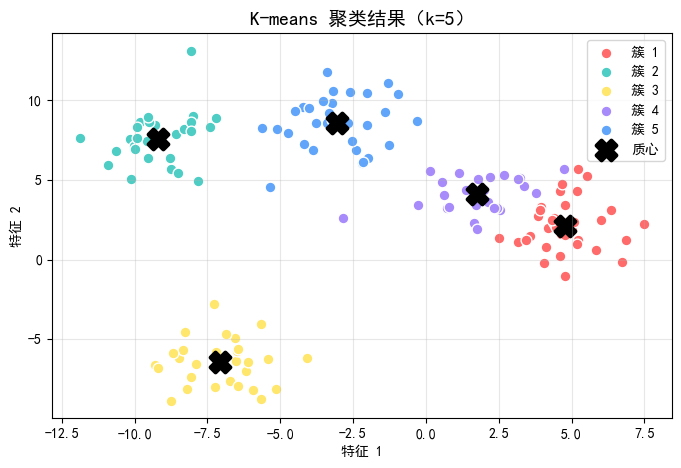


4. 手肘法选择最优 k 值


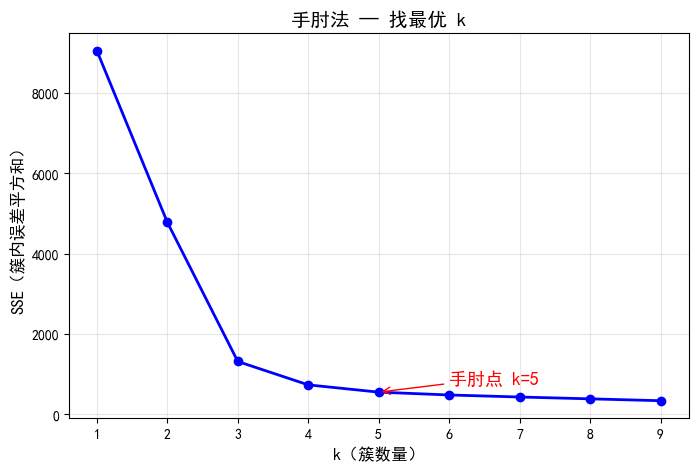

手肘法解释：
  随着 k 增大，SSE 不断下降
  在 k=5 处出现明显拐点（手肘）
  之后下降变缓 → 最优 k = 5 ✅

5. 对比验证：KNN（分类）vs K-means（聚类）
新样本: [0 5]
KNN 预测它属于: 簇 4
最近的 5 个邻居索引: [127  98   8   2  21]
K-means 质心:
[[ 4.77703448  2.13543291]
 [-9.18430226  7.5576926 ]
 [-7.08526132 -6.45033422]
 [ 1.74763551  4.08777541]
 [-3.05478841  8.57447876]]

✅ 总结：
  • K-means 先无监督聚类，发现 5 个群体
  • KNN 再利用聚类结果做分类预测
  • 两者都用欧氏距离，都需特征缩放


In [12]:
# ============================================================
# K-means 聚类 — 自动发现数据中的群体
# 无监督学习：没有标签，让数据自己说话
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# 设置 matplotlib 中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示异常

# ---- 1. 生成模拟数据（3 个簇）----
print("=" * 60)
print("1. 生成模拟数据（5 个自然簇）")
print("=" * 60)

# 造 150 个样本，天然分成 5 堆
X_blob, y_true = make_blobs(n_samples=150, centers=5, 
                            cluster_std=1.5, random_state=42)

print(f"数据形状: {X_blob.shape}")
print(f"前 5 个样本:\n{X_blob[:5]}")
print()

# ---- 2. 训练 K-means 模型 ----
print("=" * 60)
print("2. K-means 聚类（k=5）")
print("=" * 60)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_blob)

labels = kmeans.labels_          # 每个样本的簇标签
centers = kmeans.cluster_centers_  # 5 个质心的坐标
print(f"簇标签: {labels}")
print(f"质心坐标:\n{centers}")
print()

# ---- 3. 可视化聚类结果 ----
print("=" * 60)
print("3. 聚类结果可视化")
print("=" * 60)

plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#A78BFA', '#60A5FA']

for i in range(5):
    plt.scatter(X_blob[labels == i, 0], X_blob[labels == i, 1],
                c=colors[i], label=f'簇 {i+1}', edgecolors='white', s=60)

plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', 
            s=200, linewidths=3, label='质心')
plt.title('K-means 聚类结果（k=5）', fontsize=14)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print()

# ---- 4. 手肘法选最优 k ----
print("=" * 60)
print("4. 手肘法选择最优 k 值")
print("=" * 60)

inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blob)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2)
plt.xlabel('k（簇数量）', fontsize=12)
plt.ylabel('SSE（簇内误差平方和）', fontsize=12)
plt.title('手肘法 — 找最优 k', fontsize=14)
plt.xticks(k_range)
plt.grid(alpha=0.3)
# 标注"手肘"位置
plt.annotate('手肘点 k=5', xy=(5, inertias[4]), xytext=(6, inertias[4]+200),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=13, color='red')
plt.show()

print("手肘法解释：")
print("  随着 k 增大，SSE 不断下降")
print("  在 k=5 处出现明显拐点（手肘）")
print("  之后下降变缓 → 最优 k = 5 ✅")
print()

# ---- 5. KNN vs K-means 类比验证 ----
print("=" * 60)
print("5. 对比验证：KNN（分类）vs K-means（聚类）")
print("=" * 60)

# 用 KNN 对新点分类
from sklearn.neighbors import KNeighborsClassifier

# 假装聚类得到的标签是"真实类别"（实际中不会这么做，仅用于对比演示）
knn_demo = KNeighborsClassifier(n_neighbors=5)
knn_demo.fit(X_blob, labels)

new_point = np.array([[0, 5]])
pred_label = knn_demo.predict(new_point)
distances, indices = knn_demo.kneighbors(new_point)

print(f"新样本: {new_point[0]}")
print(f"KNN 预测它属于: 簇 {pred_label[0]+1}")
print(f"最近的 5 个邻居索引: {indices[0]}")
print(f"K-means 质心:\n{centers}")
print()
print("✅ 总结：")
print("  • K-means 先无监督聚类，发现 5 个群体")
print("  • KNN 再利用聚类结果做分类预测")
print("  • 两者都用欧氏距离，都需特征缩放")

In [7]:
import pandas as pd

# 1. 读取 Excel 文件
df = pd.read_excel('超市营业额2.xlsx', sheet_name='Sheet1')

# 2. 将日期列转为 datetime 类型（便于筛选）
df['日期'] = pd.to_datetime(df['日期'])

mask = (df['日期'] >= '2019-03-01') & (df['日期'] <= '2019-03-03')
df = df[mask].copy()

print("3月1日 ~ 3月3日 销售数据（前5行）：")
print(df.head())
print(f"\n共有 {len(df)} 条记录")

print("\n第1、3、5行中第2、4、6列的数据：")
print(df.iloc[[0, 2, 4], [1, 3, 5]])

print("\n李四销售化妆品的情况：")
print(df[(df['姓名'] == '李四') & (df['柜台'] == '化妆品')])

print("\n张三的上班次数：")
print(f"张三在3月1日~3日期间上班了 {len(df[df['姓名'] == '张三'])} 次")
print(df[df['姓名'] == '张三'])

# 4. 将表头由中文改成英文
df_en = df.rename(columns={
    '工号': 'ID', '姓名': 'Name', '日期': 'Date',
    '时段': 'Shift', '交易额': 'Amount', '柜台': 'Counter'
})
print("\n表头已改为英文（前5行）：")
print(df_en.head())

# 5. 另存副本
df_en.to_excel('超市营业额_英文版.xlsx', index=False)
print("\n✅ 已另存为：超市营业额_英文版.xlsx")

3月1日 ~ 3月3日 销售数据（前5行）：
     工号  姓名         日期           时段     交易额   柜台
0  1001  张三 2019-03-01   9：00-14：00  1664.0  化妆品
1  1002  李四 2019-03-01  14：00-21：00   954.0  化妆品
2  1003  王五 2019-03-01   9：00-14：00  1407.0   食品
3  1004  赵六 2019-03-01  14：00-21：00  1320.0   食品
4  1005  周七 2019-03-01   9：00-14：00   994.0  日用品

共有 24 条记录

第1、3、5行中第2、4、6列的数据：
   姓名          时段   柜台
0  张三  9：00-14：00  化妆品
2  王五  9：00-14：00   食品
4  周七  9：00-14：00  日用品

李四销售化妆品的情况：
      工号  姓名         日期           时段     交易额   柜台
1   1002  李四 2019-03-01  14：00-21：00   954.0  化妆品
9   1002  李四 2019-03-02  14：00-21：00  1395.0  化妆品
17  1002  李四 2019-03-03  14：00-21：00  1034.0  化妆品

张三的上班次数：
张三在3月1日~3日期间上班了 4 次
      工号  姓名         日期           时段     交易额    柜台
0   1001  张三 2019-03-01   9：00-14：00  1664.0   化妆品
7   1001  张三 2019-03-01  14：00-21：00  1442.0  蔬菜水果
8   1001  张三 2019-03-02   9：00-14：00  1530.0   化妆品
16  1001  张三 2019-03-03   9：00-14：00  1361.0   化妆品

表头已改为英文（前5行）：
     ID Name       Date        Shift  Amount C